In [73]:
%reset -f

from glob import glob

import easygui
import matplotlib.pyplot as plt
import numpy as np
from VicPy import VicDataSet
from geomfitty import geom3d, fit3d
from scipy.io import loadmat


In [74]:
# Declare constants

plt.rcParams["font.family"] = "serif"

DATA_DIR = easygui.diropenbox("Select Folder with out-Files")

YAW_ANGLE_FLAG = True
if YAW_ANGLE_FLAG:
    YAW_ANGLE_FILE = easygui.fileopenbox("Select the Yaw Angle Time-Series File")
else:
    pass


Text(0.5, 0, 'Yaw Angle [°]')

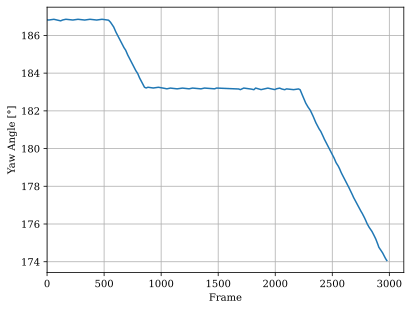

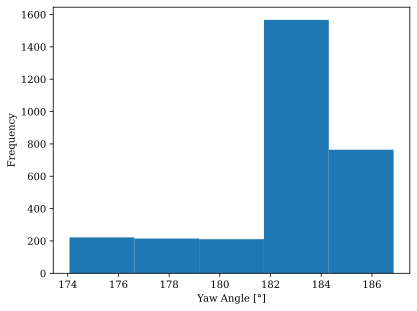

In [75]:
out_file_list = glob(DATA_DIR + "/*.out")
frame_n = 2979 # len(out_file_list)

yaw_angle_array = np.array(loadmat(YAW_ANGLE_FILE)["yaw_wea"])[:frame_n]

yaw_angle_mean = np.mean(yaw_angle_array)
yaw_angle_med = np.median(yaw_angle_array)

fig1, ax1 = plt.subplots()
ax1.plot(yaw_angle_array)
ax1.set_xlim(0)
ax1.set_xlabel("Frame")
ax1.set_ylabel("Yaw Angle [°]")
ax1.grid()

fig2, ax2 = plt.subplots()
ax2.hist(yaw_angle_array, bins=5)
ax2.set_ylabel("Frequency")
ax2.set_xlabel("Yaw Angle [°]")


In [76]:
def read_file(file_name):

    data = VicDataSet()  # Creates an instance of a VicDataSet() class

    if not data.load(file_name):  # Tries to load a .out file into the VicDataSet() instance, it exits if it fails
        print("Could not load data set\n\n")
        exit(-1)

    size = 0
    for aoi in range(data.numData()):  # The numData() method returns the number of areas of interest in the dataset
        d = data.data(aoi)  # Returns a pointer to VicData objet for the specific AOI in the dataset
        size += d.matrixSize()

    found_array = np.empty((size), int)  # gibt an, ob ein Subset gefunden wurde. 1 wenn gefunden, sonst 0
    coordinates = np.empty((size, 3), float)  # enthaelt die Koordinaten der Subsets
    xyz_sigmas = np.empty((size, 3), float)  # enthaelt die Sigma-Werte eines Subsets
    aoi_number = np.empty((size), int)  # gibt an in welcher AOI ein Subset liegt
    index_in_aoi = np.empty((size), int)  # Index des Subsets innerhalb der AOI

    index = 0
    for aoi in range(data.numData()):
        d = data.data(aoi)
        rows = d.asArray(["sigma", "X", "Y", "Z", "U", "V", "W", "SIGMA_X", "SIGMA_Y",
                          "SIGMA_Z"])  #TODO: This array is the same as the hardcoded one on top?
        rows = rows.view(np.float32).reshape(rows.shape[0], -1)

        rows = rows.T  # TODO: I'm pretty sure this transpose is not needed
        found_array_for_aoi = np.where(rows[0] < 0, 0, 1)

        coordinates_for_aoi = (rows[1:4] + rows[4:7]).T
        xyz_sigma_for_aoi = rows[7:10].T

        found_array[index: index + len(found_array_for_aoi)] = found_array_for_aoi
        coordinates[index: index + len(coordinates_for_aoi)] = coordinates_for_aoi
        xyz_sigmas[index: index + len(xyz_sigma_for_aoi)] = xyz_sigma_for_aoi
        aoi_number[index: index + len(xyz_sigma_for_aoi)] = np.full((len(xyz_sigma_for_aoi)),
                                                                    aoi)
        index_in_aoi[index: index + len(xyz_sigma_for_aoi)] = np.arange(len(found_array_for_aoi))

        index += len(found_array_for_aoi)

    return found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi


Circle3D(center=[13960.169561297564, 28868.635453515933, -289172.31680352683], direction=[0.1247860128449439, -0.39926188796410206, -0.9083052327371027], radius=41905.434904709386)
Circle3D(center=[15150.404212904807, 28403.866094757428, -289016.8409617374], direction=[0.07790368371346863, 0.3982102808399427, 0.9139800809083565], radius=41896.87571429259)


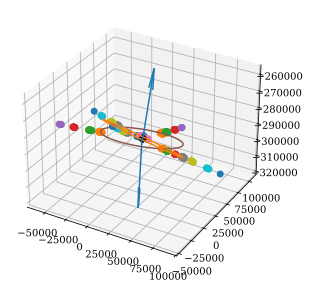

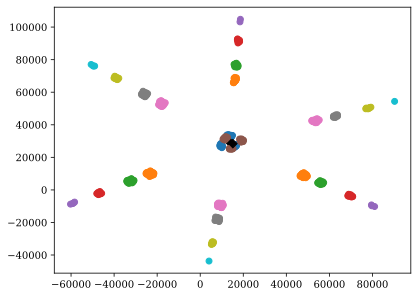

In [79]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(projection="3d")

fig2 = plt.figure()
ax2 = fig2.add_subplot()

circle_dir_list = []
circle_center_list = []
for out_file in out_file_list:
    found_array, coordinates, xyz_sigmas, aoi_number, index_in_aoi = read_file(out_file)

    aoi_mean_coord = []
    for aoi in np.unique(aoi_number):
        bool_mask = (aoi_number == aoi) & (found_array > 0)
        aoi_mean_coord.append(np.mean(coordinates[bool_mask, :][::100], axis=0))

    aoi_mean_coord = np.array(aoi_mean_coord)
    center_point = np.mean(aoi_mean_coord, axis=0)

    dist_array = np.linalg.norm(aoi_mean_coord - center_point, axis=1)
    arg_dist = np.argsort(dist_array)

    dist_array = dist_array[arg_dist]

    for i in range(5):
        bool_mask = ((aoi_number == arg_dist[3*i]) | (aoi_number == arg_dist[3*i+1]) | (aoi_number == arg_dist[3*i+2])) & (found_array > 0)
        ax1.plot(coordinates[bool_mask
        , 0][::100], coordinates[bool_mask, 1][::100], coordinates[bool_mask, 2][::100], linestyle='', marker='o', alpha=1)

        ax2.plot(coordinates[bool_mask
        , 0][::100], coordinates[bool_mask, 1][::100], linestyle='', marker='o', alpha=1)

    inner_rad = np.mean(dist_array[3:6])/1000
    initial_guess = geom3d.Circle3D(center_point, [1, 0, 0], inner_rad)
    circle = fit3d.circle3D_fit(coordinates[((aoi_number == 3) | (aoi_number == 11) | (aoi_number == 7)) & (found_array > 0)], initial_guess=initial_guess)

    circle_center_list.append(circle.center)
    circle_dir_list.append(circle.direction)

    random = np.array([1, 0, 0])
    u = np.cross(circle.direction, random)
    v = np.cross(circle.direction, u)
    theta = np.linspace(0, 2 * np.pi, 100)

    circle_pts = circle.radius * (np.outer(u, np.cos(theta)) + np.outer(v, np.sin(theta)))
    circle_pts = circle.center + circle_pts.T

    ax1.plot(circle.center[0], circle.center[1], circle.center[2], marker='D', color='black')
    ax1.plot(circle_pts[:, 0],circle_pts[:, 1],circle_pts[:, 2])
    ax1.quiver(circle.center[0], circle.center[1], circle.center[2], circle.direction[0]*circle.radius, circle.direction[1]*circle.radius, circle.direction[2]*circle.radius)

    ax2.plot(circle.center[0], circle.center[1], marker='D', color='black')

    print(circle)

circle_center_array = np.array(circle_center_list)
circle_dir_array = np.array(circle_dir_list)